In [1]:
import os

def read_loss(filename):
    txt = open(filename, "r")
    lines = txt.readlines()
    txt.close()

    metrics = {}
    for line in lines:
        if line.lower().startswith('epoch'):
            line = line.split(" ")
            if len(line) < 5:
                continue
            for i in range(4, len(line), 2):
                key = line[i].replace(":", "")
                value = float(line[i+1])
                if key in metrics:
                    metrics[key].append(value)
                else:
                    metrics[key] = [value]

    return metrics

def smooth(data, window_size=10):
    smoothed = []
    for i in range(len(data)):
        if i < window_size:
            smoothed.append(data[i])
        else:
            smoothed.append(sum(data[i-window_size:i+1]) / window_size)
    return smoothed

In [12]:
baseline_loss = read_loss('../../logs/attn_output.txt')
baseline_loss.keys()
LAYER_NUM = 12

In [15]:
all_to_all = []
topk = 2
for i in range(LAYER_NUM):
    i_to_all = []
    for j in range(i):
        i_to_all.append(0)
    for j in range(i, LAYER_NUM):
        i_to_all.append(max(baseline_loss[f'Layer-{i}-to-{j}-top{topk}-Accuracy']))
    all_to_all.append(i_to_all)

In [1]:
import numpy as np
clust_num = [[2741, 1975, 1970, 1506],
             [2468, 2194, 1954, 1576],
             [2763, 1891, 1816, 1722],
             [2702, 1978, 1821, 1691],
             [2868, 2616, 1515, 1193],  
             [2814, 2108, 1754, 1516],
             [2862, 2180, 1828, 1322],
             [2861, 2211, 1655, 1465],
             [2788, 1963, 1941, 1500],
             [2825, 2460, 1581, 1326],
             [2862, 2519, 1520, 1291]]
clust_num = np.array(clust_num)
all_to_all = []
for i in range(len(clust_num)):
    i_to_all = []
    for j in range(i):
        i_to_all.append(0)
    for j in range(i, len(clust_num)):
        acc = 0
        for k in range(4):
            acc += min(1,clust_num[j][k] / clust_num[i][k]) * clust_num[i][k]
        i_to_all.append(acc / clust_num[i].sum())
    all_to_all.append(i_to_all)

Text(0.5, 1.0, 'Top-6 Accuracy Attn-output')

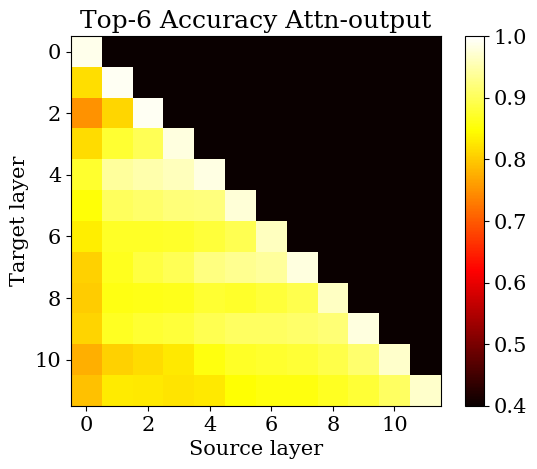

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

all_to_all = np.array(all_to_all)
plt.imshow(all_to_all.T, cmap='hot', vmin=0.4, vmax=1)
plt.colorbar()
plt.xlabel('Source layer')
plt.ylabel('Target layer')
plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'DejaVu Math TeX Gyre'
# x axis intiger
plt.xticks(np.arange(0, LAYER_NUM, 2))
plt.yticks(np.arange(0, LAYER_NUM, 2))
plt.title(f'Top-6 Accuracy Attn-output')

In [30]:
all_to_all[0][1]

0.6044

In [77]:
import matplotlib.pyplot as plt
section = 3
res = []
for layer in range(24):
    res.append(baseline_loss[f'Layer-{layer}-top30-Accuracy'][section])
print(sum(res) / len(res))

# plt.figure(figsize=(5, 1))
# plt.plot(res)
# plt.rcParams.update({'font.size': 14})
# plt.xlabel('Layer')
# # plt.vlines(9, 0, 1.1, colors='k', linestyles='dashed')
# # plt.vlines(17, 0, 1.1, colors='k', linestyles='dashed')
# # plt.vlines(19, 0, 1.1, colors='k', linestyles='dashed')
# plt.title('Reverse Accuracy Every 24 Layers')
# plt.xticks(range(1, 25, 3))
# plt.ylabel('Accuracy')

# # plt.legend()
# plt.ylim(0.5, 1.1)
# plt.show()

0.9913541666666666


In [53]:
import matplotlib.pyplot as plt


sec1_layer_top6_acc = [baseline_loss[f'Layer-{l}-top6-Accuracy'][99] for l in range(0, 24)]
sec1_layer_top4_acc = [baseline_loss[f'Layer-{l}-top4-Accuracy'][99] for l in range(0, 24)]
sec2_layer_top6_acc = [baseline_loss[f'Layer-{l}-top6-Accuracy'][199] for l in range(0, 24)]
sec2_layer_top4_acc = [baseline_loss[f'Layer-{l}-top4-Accuracy'][199] for l in range(0, 24)]
sec3_layer_top6_acc = [baseline_loss[f'Layer-{l}-top6-Accuracy'][299] for l in range(0, 24)]
sec3_layer_top4_acc = [baseline_loss[f'Layer-{l}-top4-Accuracy'][299] for l in range(0, 24)]
sec4_layer_top6_acc = [baseline_loss[f'Layer-{l}-top6-Accuracy'][399] for l in range(0, 24)]
sec4_layer_top4_acc = [baseline_loss[f'Layer-{l}-top4-Accuracy'][399] for l in range(0, 24)]


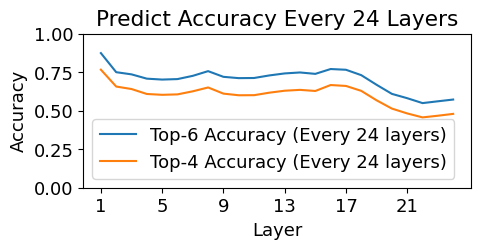

In [71]:
plt.close()
plt.figure(figsize=(5, 2))
plt.plot(range(1,25), sec1_layer_top6_acc, label='Top-6 Accuracy (Every 24 layers)')
plt.plot(range(1,25), sec1_layer_top4_acc, label='Top-4 Accuracy (Every 24 layers)')
# plt.plot(range(1,25), sec2_layer_top6_acc, label='Top-6 Accuracy (Every 12 layers)')
# plt.plot(range(1,25), sec2_layer_top4_acc, label='Top-4 Accuracy (Every 12 layers)')
# plt.plot(range(1,25), sec3_layer_top6_acc, label='Top-6 Accuracy (Every 8 layers)')
# plt.plot(range(1,25), sec3_layer_top4_acc, label='Top-4 Accuracy (Every 8 layers)')
# plt.plot(range(1,25), sec4_layer_top6_acc, label='Top-6 Accuracy (Every 6 layers)')
# plt.plot(range(1,25), sec4_layer_top4_acc, label='Top-4 Accuracy (Every 6 layers)')

plt.rcParams.update({'font.size': 13})
plt.xlabel('Layer')
# plt.vlines(13, 0, 1, colors='k', linestyles='dashed')
# plt.vlines(17, 0, 1, colors='k', linestyles='dashed')
# plt.vlines(19, 0, 1, colors='k', linestyles='dashed')
plt.title('Predict Accuracy Every 24 Layers')
plt.xticks(range(1, 25, 4))
plt.ylabel('Accuracy')

plt.legend()
plt.ylim(0, 1)
plt.show()

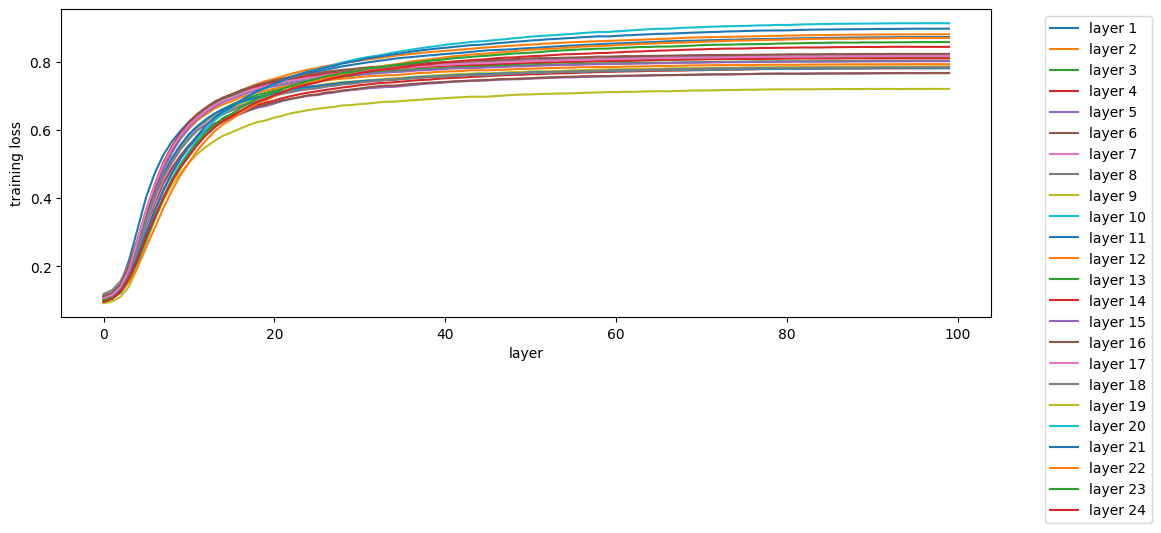

In [4]:
import matplotlib.pyplot as plt

window = 1000
# plt.plot(baseline_loss['Loss'][0:4000:], label='normal')
plt.close()
plt.figure(figsize=(12, 4))

for l in range(0, 24):
    plt.plot(baseline_loss[f'Layer-{l}-top6-Accuracy'], label=f'layer {l+1}')
# set bigger font size
# plt.rcParams.update({'font.size': 10})
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('layer')
plt.ylabel('training loss')
plt.show()

